In [1]:
pip install gymnasium torch numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque


In [21]:
# Hyperparameters
GAMMA = 0.99
TAU = 0.005
ACTOR_LR = 1e-4
CRITIC_LR = 1e-3
BUFFER_SIZE = 100000
BATCH_SIZE = 64
EPISODES = 1000

POLICY_NOISE = 0.2
NOISE_CLIP = 0.5
POLICY_DELAY = 2
EXPLORATION_NOISE = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Replay buffer**

In [11]:
class ReplayBuffer:

    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.FloatTensor(states).to(device),
            torch.FloatTensor(actions).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)



**Networks**

In [12]:
# Actor Network
class Actor(nn.Module):

    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()

        self.max_action = max_action

        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, action_dim)

    def forward(self, state):

        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))

        return torch.tanh(self.out(x)) * self.max_action


# Twin Critic Network
class Critic(nn.Module):

    def __init__(self, state_dim, action_dim):
        super().__init__()

        # Q1
        self.l1 = nn.Linear(state_dim + action_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 1)

        # Q2
        self.l4 = nn.Linear(state_dim + action_dim, 256)
        self.l5 = nn.Linear(256, 256)
        self.l6 = nn.Linear(256, 1)

    def forward(self, state, action):

        sa = torch.cat([state, action], 1)

        # Q1
        q1 = F.relu(self.l1(sa))
        q1 = F.relu(self.l2(q1))
        q1 = self.l3(q1)

        # Q2
        q2 = F.relu(self.l4(sa))
        q2 = F.relu(self.l5(q2))
        q2 = self.l6(q2)

        return q1, q2

    def Q1(self, state, action):

        sa = torch.cat([state, action], 1)

        q1 = F.relu(self.l1(sa))
        q1 = F.relu(self.l2(q1))
        q1 = self.l3(q1)

        return q1

**Training Loop**

In [22]:
def train():

    env = gym.make("Pendulum-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    actor = Actor(state_dim, action_dim, max_action).to(device)
    actor_target = Actor(state_dim, action_dim, max_action).to(device)

    critic = Critic(state_dim, action_dim).to(device)
    critic_target = Critic(state_dim, action_dim).to(device)

    actor_target.load_state_dict(actor.state_dict())
    critic_target.load_state_dict(critic.state_dict())

    actor_opt = optim.Adam(actor.parameters(), lr=ACTOR_LR)
    critic_opt = optim.Adam(critic.parameters(), lr=CRITIC_LR)

    buffer = ReplayBuffer(BUFFER_SIZE)

    rewards_per_episode = []
    total_it = 0

    for episode in range(EPISODES):

        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)

            action = actor(state_t).detach().cpu().numpy()[0]

            action += np.random.normal(0, EXPLORATION_NOISE, size=action_dim)
            action = np.clip(action, -max_action, max_action)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            buffer.push((state, action, reward, next_state, done))

            state = next_state
            total_reward += reward

            if len(buffer) < BATCH_SIZE:
                continue

            total_it += 1

            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            with torch.no_grad():

                noise = (
                    torch.randn_like(actions) * POLICY_NOISE
                ).clamp(-NOISE_CLIP, NOISE_CLIP)

                next_action = (actor_target(next_states) + noise).clamp(
                    -max_action, max_action
                )

                target_Q1, target_Q2 = critic_target(next_states, next_action)
                target_Q = torch.min(target_Q1, target_Q2)

                y = rewards + GAMMA * (1 - dones) * target_Q

            current_Q1, current_Q2 = critic(states, actions)

            critic_loss = (
                F.mse_loss(current_Q1, y) +
                F.mse_loss(current_Q2, y)
            )

            critic_opt.zero_grad()
            critic_loss.backward()
            critic_opt.step()

            # Delayed actor update
            if total_it % POLICY_DELAY == 0:

                actor_loss = -critic.Q1(states, actor(states)).mean()

                actor_opt.zero_grad()
                actor_loss.backward()
                actor_opt.step()

                # Soft update
                for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                    target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

                for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                    target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        rewards_per_episode.append(total_reward)

        if episode % 100 == 0:
            print("Episode:", episode, "Reward:", total_reward)

    env.close()
    return rewards_per_episode
    

Episode: 0 Reward: -1206.9913168412318
Episode: 100 Reward: -375.765919862125
Episode: 200 Reward: -122.45589356255235
Episode: 300 Reward: -121.85164576930232
Episode: 400 Reward: -115.3445177769756
Episode: 500 Reward: -125.63433658251013
Episode: 600 Reward: -242.7683344983441
Episode: 700 Reward: -117.18292089244599
Episode: 800 Reward: -10.841140517988823
Episode: 900 Reward: -242.34534398480375


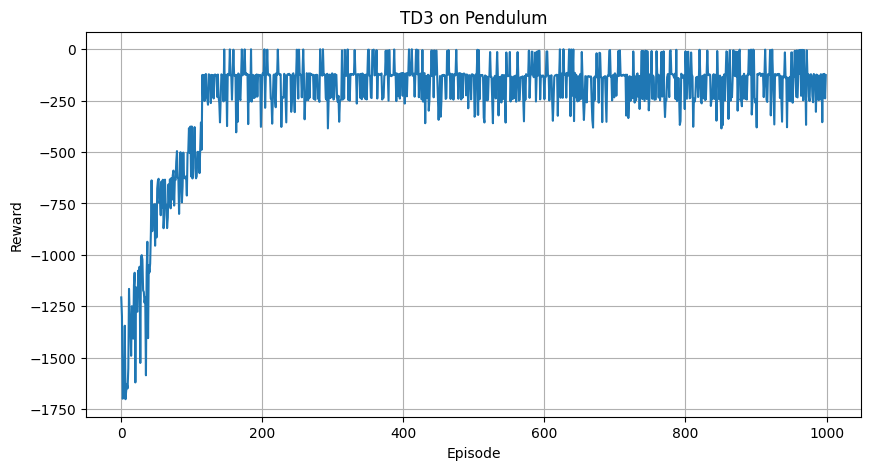

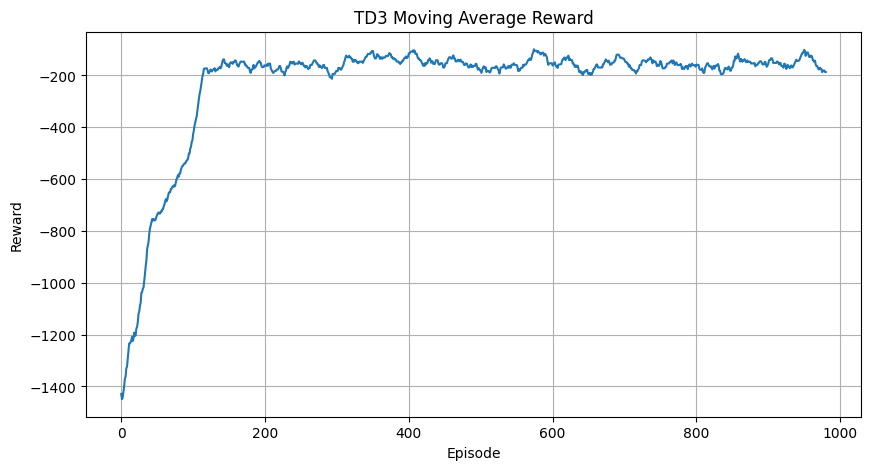

In [23]:
rewards = train()

smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("TD3 on Pendulum")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(smoothed)
plt.title("TD3 Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()
